In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import librosa
import soundfile as sf
from tqdm import tqdm
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.multiclass import OneVsOneClassifier, OneVsRestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report
from sklearn.decomposition import PCA
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# preparation

In [59]:
path = "dataset"

## func

In [60]:
MAX_DURATION = 12

def extract_features(audio_path):
    y, sr = librosa.load(audio_path, sr=None, duration=MAX_DURATION)

    mels = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=20)
    mels_db = librosa.power_to_db(mels, ref=np.max)

    zcr = librosa.feature.zero_crossing_rate(y)

    return np.hstack([
        np.mean(mels_db, axis=1),
        np.std(mels_db, axis=1),
        np.mean(zcr, axis=1),
        np.std(zcr, axis=1)
    ])

In [61]:
SEGMENT_DURATION = 12
MIN_LONG_AUDIO = 60

def split_long_audio_files(source_dir, output_dir):
    os.makedirs(output_dir, exist_ok=True)

    class_dirs = [
        d for d in os.listdir(source_dir)
        if os.path.isdir(os.path.join(source_dir, d))
    ]

    for class_label in tqdm(class_dirs, desc="Splitting long audio"):
        source_class_path = os.path.join(source_dir, class_label)
        output_class_path = os.path.join(output_dir, class_label)
        os.makedirs(output_class_path, exist_ok=True)

        files = [
            f for f in os.listdir(source_class_path)
            if f.lower().endswith(('.wav', '.mp3'))
        ]

        for file in files:
            file_path = os.path.join(source_class_path, file)

            try:
                y, sr = librosa.load(file_path, sr=None)
                duration = librosa.get_duration(y=y, sr=sr)

                base_name = file.rsplit('.', 1)[0]

                if duration <= MIN_LONG_AUDIO:
                    save_path = os.path.join(output_class_path, f"{base_name}.wav")
                    if not os.path.exists(save_path):
                        sf.write(save_path, y, sr)
                    continue

                segment_samples = SEGMENT_DURATION * sr

                for i, start in enumerate(range(0, len(y), segment_samples)):
                    segment = y[start:start + segment_samples]

                    if len(segment) < sr:
                        continue

                    save_path = os.path.join(
                        output_class_path,
                        f"{base_name}_part_{i + 1}.wav"
                    )

                    sf.write(save_path, segment, sr)

            except Exception as e:
                print(f"Помилка під час обробки {file_path}: {e}")

In [62]:
def process_emotion_folders(audio_path):
    X, y = [], []
    
    emotion_dirs = [d for d in os.listdir(audio_path) if os.path.isdir(os.path.join(audio_path, d))]

    for emotion_label in tqdm(emotion_dirs, desc="Processing sounds"):
        emotion_path = os.path.join(audio_path, emotion_label)
        
        files = [f for f in os.listdir(emotion_path) if f.lower().endswith(('.wav', '.mp3'))]
        
        for file in files:
            file_path = os.path.join(emotion_path, file)
            
            features = extract_features(file_path)
            if features is not None:
                X.append(features)
                y.append(emotion_label)
                
    return np.array(X), np.array(y)

In [63]:
def convert_audio_to_images(source_dir, target_dir, n_mels=20):

    os.makedirs(target_dir, exist_ok=True)
    emotion_dirs = [d for d in os.listdir(source_dir) if os.path.isdir(os.path.join(source_dir, d))]

    for emotion_label in tqdm(emotion_dirs, desc="processing emotions"):
        source_emotion_path = os.path.join(source_dir, emotion_label)
        
        target_emotion_path = os.path.join(target_dir, emotion_label)
        os.makedirs(target_emotion_path, exist_ok=True)
        
        files = [f for f in os.listdir(source_emotion_path) if f.lower().endswith(('.wav', '.mp3'))]
    
        for file in files:
            file_path = os.path.join(source_emotion_path, file)
            new_file_name = file.rsplit('.', 1)[0] + '.png'
            save_path = os.path.join(target_emotion_path, new_file_name)
            
            y, sr = librosa.load(file_path, sr=22050)
                
            S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
            S_dB = librosa.power_to_db(S, ref=np.max)

            fig, ax = plt.subplots(figsize=(2, 2))
            ax.axis('off')
            fig.subplots_adjust(left=0, right=1, bottom=0, top=1) 

            librosa.display.specshow(S_dB, sr=sr, cmap='inferno', ax=ax)

            fig.savefig(save_path, format='png', dpi=100)
            plt.close(fig)

In [64]:
output_folder = "spectrograms" 
convert_audio_to_images(path, output_folder)

processing emotions: 100%|██████████| 3/3 [00:38<00:00, 12.73s/it]


## eda

In [65]:
data_info = {}

for sounds in os.listdir(path):
    sounds_folder = os.path.join(path, sounds)
    if os.path.isdir(sounds_folder):
        count = len(os.listdir(sounds_folder))
        data_info[sounds] = count

df_dist = pd.DataFrame(list(data_info.items()), columns=['Type', 'Count'])
df_dist = df_dist.sort_values(by='Count', ascending=False)
df_dist

,Type,Count
1,air vehicles,106
2,weapons,99
0,tank,79


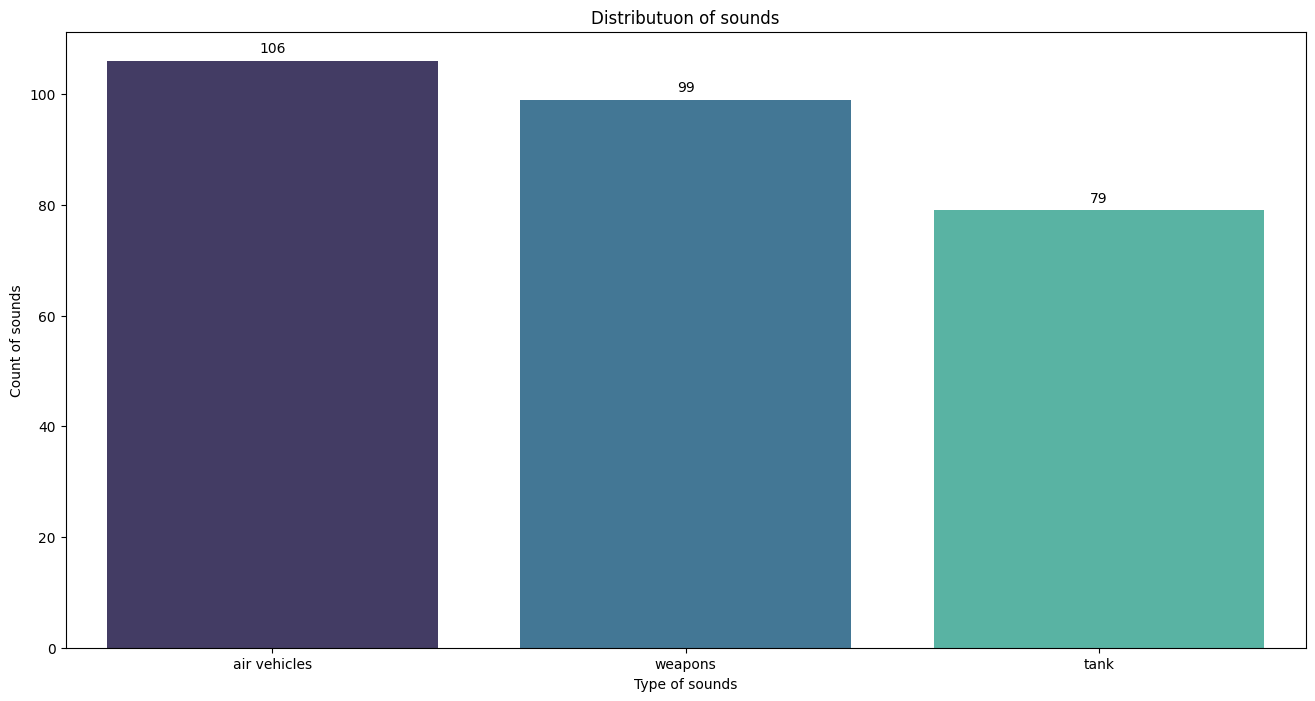

In [66]:
f, ax = plt.subplots(1, 1, figsize = (16, 8))

sns.barplot(
    data = df_dist,
    x = 'Type', 
    y = 'Count', 
    hue = 'Type',
    palette = 'mako',
    ax = ax,
    legend = False
    )

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')

ax.set(title = 'Distributuon of sounds', xlabel = 'Type of sounds', ylabel = 'Count of sounds')
plt.show()

## preprocess

In [67]:
path = "dataset"

split_long_audio_files(
    source_dir=path,
    output_dir="dataset_processed"
)

path = "dataset_processed"

Splitting long audio: 100%|██████████| 3/3 [00:23<00:00,  7.68s/it]


In [68]:
X_raw, y_raw = process_emotion_folders(path)

Processing sounds: 100%|██████████| 3/3 [00:27<00:00,  9.02s/it]


In [69]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X_raw, y_raw, test_size=0.2, random_state=90, stratify=y_raw)

In [70]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

In [71]:
X_train_df = pd.DataFrame(X_train)
y_train_df = pd.DataFrame(y_train)
X_test_df = pd.DataFrame(X_test)
y_test_df = pd.DataFrame(y_test)

In [72]:
feature_names = ([f'mel_mean_{i}' for i in range(20)] + 
                 [f'mel_std_{i}' for i in range(20)] + 
                 ['zcr_mean', 'zcr_std'])

X_train_df.columns = feature_names

In [73]:
X_test_df.columns = X_train_df.columns

## vector eda

In [74]:
X_train_df.head()

,mel_mean_0,mel_mean_1,mel_mean_2,mel_mean_3,mel_mean_4,mel_mean_5,mel_mean_6,mel_mean_7,mel_mean_8,mel_mean_9,...,mel_std_12,mel_std_13,mel_std_14,mel_std_15,mel_std_16,mel_std_17,mel_std_18,mel_std_19,zcr_mean,zcr_std
0,0.926766,0.058592,-0.521862,-0.597730,-0.506807,-0.482030,-0.461783,-0.279453,-0.298919,-0.338970,...,-0.696267,-0.710343,-0.716951,-0.722913,-0.672442,-0.578908,-0.458351,-0.369464,-0.586298,-0.533465
1,0.222267,-0.154226,0.443902,0.581897,0.710367,0.733797,0.676061,0.635152,0.683637,0.679484,...,1.524327,1.369994,0.935689,1.077902,1.050207,0.235418,0.348300,1.023683,-0.082358,-0.127086
2,-0.882693,-0.871457,-0.893971,-0.882293,-0.872992,-0.866402,-0.902276,-0.928416,-0.831418,-0.714406,...,2.635007,2.815117,2.984122,3.197257,3.373672,3.344204,0.121335,0.115542,3.165500,4.233972
3,-0.791079,-0.170940,0.417340,0.733479,1.022001,1.212602,1.338857,1.344750,1.252139,1.095224,...,1.210672,1.353227,1.519626,1.187353,0.402039,0.124987,0.430072,-0.144540,0.218910,-0.131096
4,0.306372,-0.357514,0.641603,1.301156,1.490870,1.605457,1.712456,1.746936,1.501560,1.506967,...,-0.530254,-0.357916,-0.138452,0.038287,-0.159240,-0.572601,-0.461137,-0.679589,0.175267,-0.328282


In [75]:
X_train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1671 entries, 0 to 1670
Data columns (total 42 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   mel_mean_0   1671 non-null   float64
 1   mel_mean_1   1671 non-null   float64
 2   mel_mean_2   1671 non-null   float64
 3   mel_mean_3   1671 non-null   float64
 4   mel_mean_4   1671 non-null   float64
 5   mel_mean_5   1671 non-null   float64
 6   mel_mean_6   1671 non-null   float64
 7   mel_mean_7   1671 non-null   float64
 8   mel_mean_8   1671 non-null   float64
 9   mel_mean_9   1671 non-null   float64
 10  mel_mean_10  1671 non-null   float64
 11  mel_mean_11  1671 non-null   float64
 12  mel_mean_12  1671 non-null   float64
 13  mel_mean_13  1671 non-null   float64
 14  mel_mean_14  1671 non-null   float64
 15  mel_mean_15  1671 non-null   float64
 16  mel_mean_16  1671 non-null   float64
 17  mel_mean_17  1671 non-null   float64
 18  mel_mean_18  1671 non-null   float64
 19  mel_me

# model training

## log regression

## svm

### OneVSOne

In [76]:
ovo = OneVsOneClassifier(SVC(random_state=90))

param_random_ovo = {
    "estimator__C": [0.1, 1, 10],
    "estimator__kernel": ['linear', 'rbf', 'poly'],
    "estimator__gamma": ['scale', 'auto']
}

In [77]:
random_ovo = RandomizedSearchCV(ovo, param_random_ovo, cv=10, random_state=90, n_jobs=-1, scoring='f1_macro')
random_ovo.fit(X_train, y_train)
print("best OvO params:", random_ovo.best_params_)

best OvO params: {'estimator__kernel': 'rbf', 'estimator__gamma': 'scale', 'estimator__C': 10}


In [78]:
best_ovo = random_ovo.best_estimator_

In [79]:
y_pred_ovo = best_ovo.predict(X_test)

In [80]:
print(classification_report(y_test, y_pred_ovo))

              precision    recall  f1-score   support

air vehicles       0.90      0.92      0.91       185
        tank       0.91      0.85      0.88       136
     weapons       0.83      0.88      0.85        97

    accuracy                           0.89       418
   macro avg       0.88      0.88      0.88       418
weighted avg       0.89      0.89      0.89       418



### OneVsRest

In [81]:
ovr = OneVsRestClassifier(SVC(random_state=90))

param_random_ovr = {
    "estimator__C": [0.1, 1, 10],
    "estimator__kernel": ['linear', 'rbf', 'poly'],
    "estimator__gamma": ['scale', 'auto']
}

In [82]:
random_ovr = RandomizedSearchCV(ovr, param_random_ovr, cv=10, random_state=90, n_jobs=-1, scoring='f1_macro')
random_ovr.fit(X_train, y_train)
print("best OvR params:", random_ovr.best_params_)

best OvR params: {'estimator__kernel': 'rbf', 'estimator__gamma': 'scale', 'estimator__C': 10}


In [83]:
best_ovr = random_ovr.best_estimator_

In [84]:
y_pred_ovr = best_ovr.predict(X_test)

In [85]:
print(classification_report(y_test, y_pred_ovr))

              precision    recall  f1-score   support

air vehicles       0.89      0.92      0.91       185
        tank       0.91      0.85      0.88       136
     weapons       0.84      0.87      0.85        97

    accuracy                           0.89       418
   macro avg       0.88      0.88      0.88       418
weighted avg       0.89      0.89      0.89       418



## boosting

In [86]:
boosting_model = GradientBoostingClassifier(random_state=90)

boosting_model.fit(X_train, y_train)

y_pred_boosting = boosting_model.predict(X_test)

print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_boosting))
print(classification_report(y_test, y_pred_boosting))

Gradient Boosting Accuracy: 0.8277511961722488
              precision    recall  f1-score   support

air vehicles       0.85      0.84      0.84       185
        tank       0.84      0.84      0.84       136
     weapons       0.77      0.79      0.78        97

    accuracy                           0.83       418
   macro avg       0.82      0.82      0.82       418
weighted avg       0.83      0.83      0.83       418



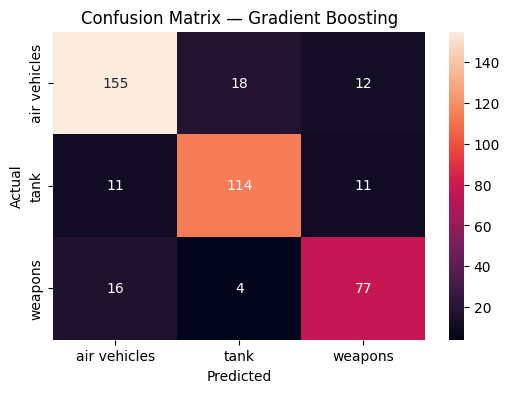

In [87]:
cm = confusion_matrix(y_test, y_pred_boosting)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=boosting_model.classes_,
    yticklabels=boosting_model.classes_
)

plt.title("Confusion Matrix — Gradient Boosting")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [88]:
param_dist = {
    "n_estimators": [50, 100, 150, 200],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [2, 3, 4, 5],
    "subsample": [0.7, 0.8, 0.9, 1.0]
}

boosting_search = RandomizedSearchCV(
    estimator=GradientBoostingClassifier(random_state=90),
    param_distributions=param_dist,
    n_iter=10,
    scoring="f1_macro",
    cv=3,
    random_state=90,
    n_jobs=-1
)

boosting_search.fit(X_train, y_train)

print("Best parameters:", boosting_search.best_params_)
print("Best CV score:", boosting_search.best_score_)

Best parameters: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.2}
Best CV score: 0.8341463788603004


In [89]:
best_boosting_model = boosting_search.best_estimator_

y_pred_best_boosting = best_boosting_model.predict(X_test)

print("Tuned Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_best_boosting))
print(classification_report(y_test, y_pred_best_boosting))

Tuned Gradient Boosting Accuracy: 0.861244019138756
              precision    recall  f1-score   support

air vehicles       0.88      0.89      0.88       185
        tank       0.90      0.87      0.88       136
     weapons       0.77      0.80      0.79        97

    accuracy                           0.86       418
   macro avg       0.85      0.85      0.85       418
weighted avg       0.86      0.86      0.86       418



In [91]:
results_boosting = pd.DataFrame({
    "Model": ["Baseline Gradient Boosting", "Tuned Gradient Boosting"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_boosting),
        accuracy_score(y_test, y_pred_best_boosting)
    ],
    "F1 macro": [
        classification_report(y_test, y_pred_boosting, output_dict=True)["macro avg"]["f1-score"],
        classification_report(y_test, y_pred_best_boosting, output_dict=True)["macro avg"]["f1-score"]
    ]
})

results_boosting

,Model,Accuracy,F1 macro
0,Baseline Gradient Boosting,0.827751,0.821549
1,Tuned Gradient Boosting,0.861244,0.851957


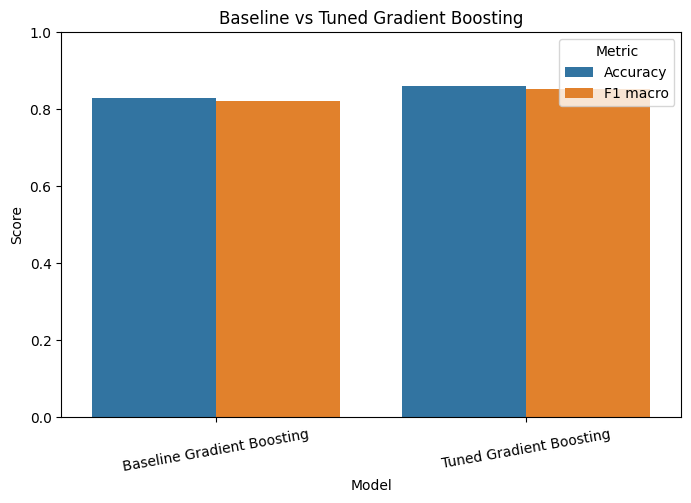

In [92]:
results_boosting_melted = results_boosting.melt(
    id_vars="Model",
    value_vars=["Accuracy", "F1 macro"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=results_boosting_melted,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.title("Baseline vs Tuned Gradient Boosting")
plt.ylim(0, 1)
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=10)
plt.show()

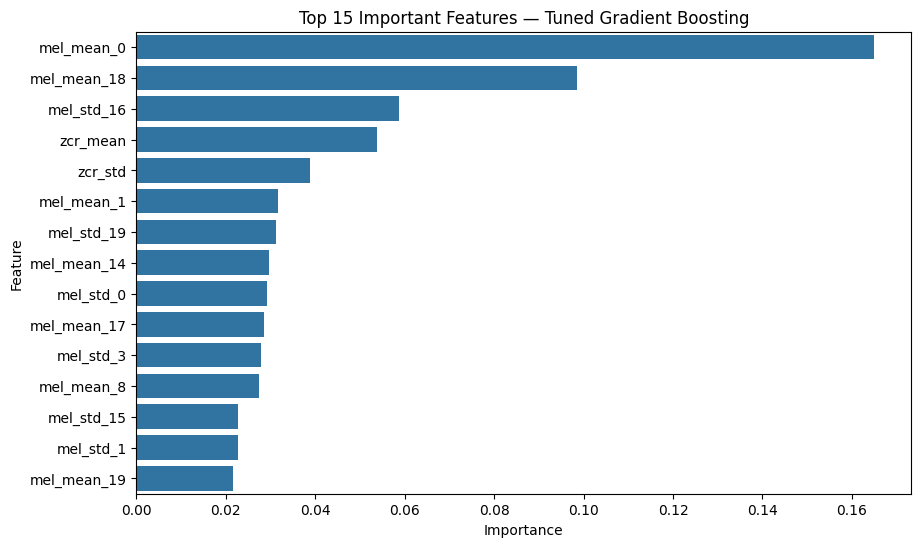

In [93]:
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": best_boosting_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Important Features — Tuned Gradient Boosting")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [94]:
report_dict = classification_report(
    y_test,
    y_pred_best_boosting,
    output_dict=True
)

class_metrics = pd.DataFrame(report_dict).T
class_metrics = class_metrics.loc[
    [label for label in best_boosting_model.classes_],
    ["precision", "recall", "f1-score"]
]

class_metrics

,precision,recall,f1-score
air vehicles,0.881720,0.886486,0.884097
tank,0.900763,0.867647,0.883895
weapons,0.772277,0.804124,0.787879


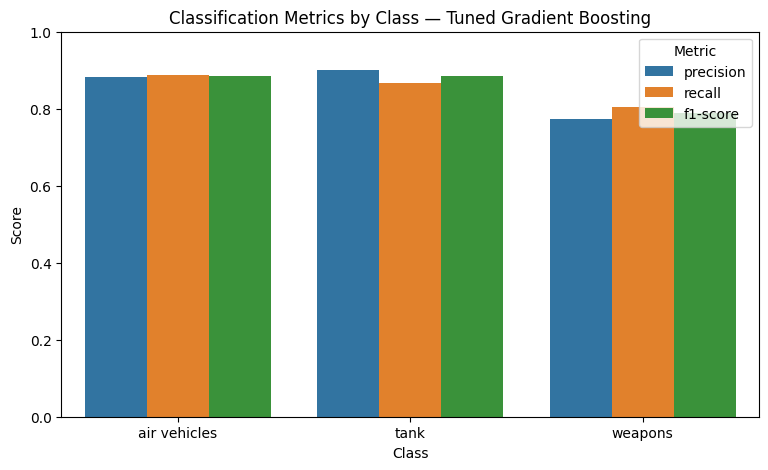

In [95]:
class_metrics_melted = class_metrics.reset_index().melt(
    id_vars="index",
    value_vars=["precision", "recall", "f1-score"],
    var_name="Metric",
    value_name="Score"
)

class_metrics_melted = class_metrics_melted.rename(columns={"index": "Class"})

plt.figure(figsize=(9, 5))
sns.barplot(
    data=class_metrics_melted,
    x="Class",
    y="Score",
    hue="Metric"
)

plt.title("Classification Metrics by Class — Tuned Gradient Boosting")
plt.ylim(0, 1)
plt.xlabel("Class")
plt.ylabel("Score")
plt.show()

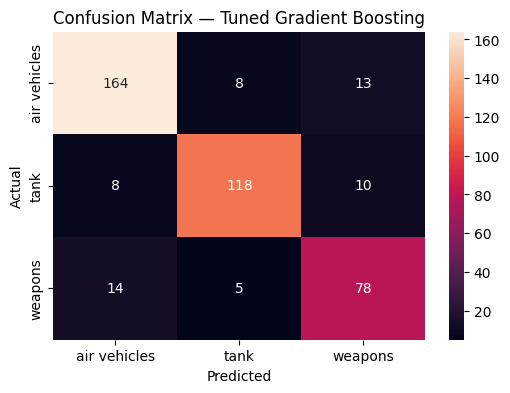

In [90]:
cm = confusion_matrix(y_test, y_pred_best_boosting)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=best_boosting_model.classes_,
    yticklabels=best_boosting_model.classes_
)

plt.title("Confusion Matrix — Tuned Gradient Boosting")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()